<a href="https://colab.research.google.com/github/slwilliams055/DS3001-SP26/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/slwilliams055/linear_models.git

Cloning into 'linear_models'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 71 (delta 21), reused 12 (delta 12), pack-reused 40 (from 2)
Receiving objects: 100% (71/71), 4.30 MiB | 5.52 MiB/s, done.
Resolving deltas: 100% (21/21), done.


    sale_date  sale_price  house_square_feet  attic_finished_square_feet  \
0  2020-01-02      380000               2157                           0   
1  2020-01-02      383000               2238                           0   
2  2020-01-01      419900               1452                           0   
3  2020-01-02      251660                832                           0   
4  2020-01-02      500000               1780                           0   

   basement_square_feet  attached_garage_square_feet  \
0                     0                          528   
1                     0                          396   
2                     0                            0   
3                     0                            0   
4                   384                          484   

   detached_garage_square_feet  fireplaces        hvac_description  \
0                            0           0  Warm and Cool Air Zone   
1                            0           0              Forced Air

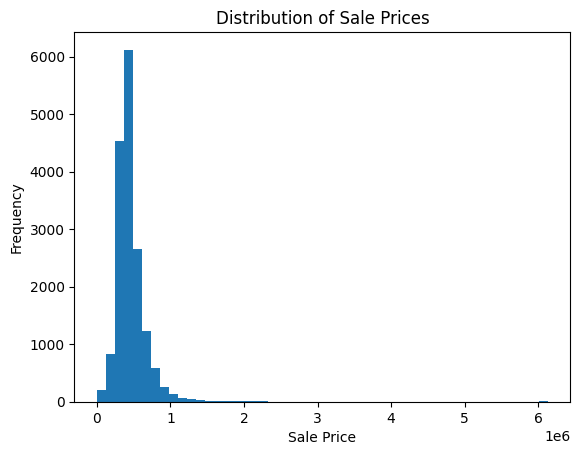

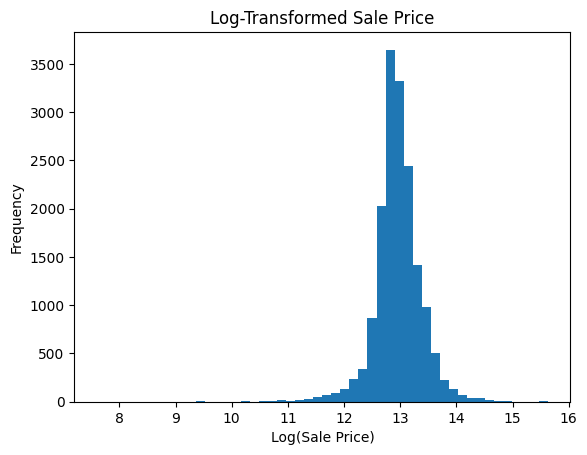

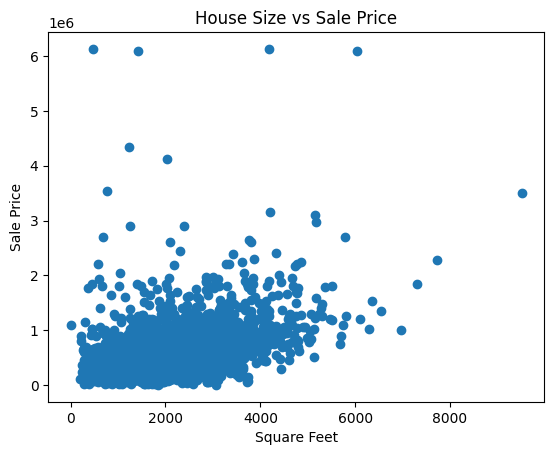

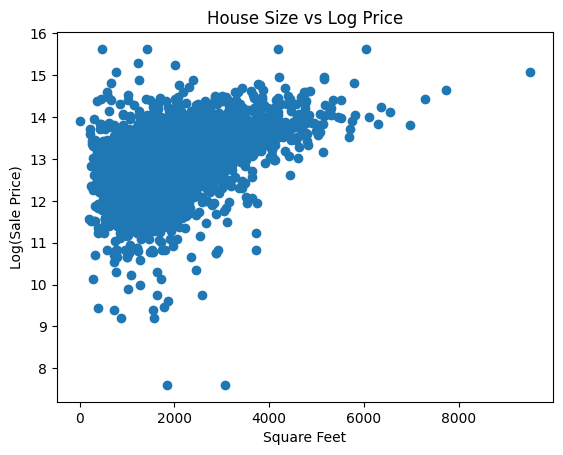

In [2]:
# Clean
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("linear_models/lab/data/pierce_county_house_sales.csv")
print(df.head())
print(df.info())

df['sale_date'] = pd.to_datetime(df['sale_date']) # Convert sale_date to datetime
print(df.isnull().sum()) # Check missing values
df = df.drop(columns=['waterfront_type', 'view_quality']) # Drop columns with too many missing values
df = df.dropna() # Drop remaining rows with small number of missing values
print(df.isnull().sum())
print(df.describe())

# distribution of sale prices
plt.figure()
plt.hist(df['sale_price'], bins=50)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

# log scale distribution of sale prices
df['log_price'] = np.log(df['sale_price'])
plt.figure()
plt.hist(df['log_price'], bins=50)
plt.title("Log-Transformed Sale Price")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Frequency")
plt.show()

# scatterplot of size vs price
plt.figure()
plt.scatter(df['house_square_feet'], df['sale_price'])
plt.title("House Size vs Sale Price")
plt.xlabel("Square Feet")
plt.ylabel("Sale Price")
plt.show()

# log distribution
plt.figure()
plt.scatter(df['house_square_feet'], df['log_price'])
plt.title("House Size vs Log Price")
plt.xlabel("Square Feet")
plt.ylabel("Log(Sale Price)")
plt.show()
# correlation
#numeric_df = df.select_dtypes(include='number')
#corr_matrix = numeric_df.corr()
#print(corr_matrix)

In [3]:
# transforming variables
# identifying categorical variables
categorical_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(include='number').columns
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Date variable
df_encoded['sale_year'] = df_encoded['sale_date'].dt.year
df_encoded['sale_month'] = df_encoded['sale_date'].dt.month
df_encoded = df_encoded.drop(columns=['sale_date']) # Drop original date column

# define x and y for regression
y = df_encoded['log_price']   # using log price
X = df_encoded.drop(columns=['sale_price', 'log_price'])

Categorical: Index(['hvac_description', 'exterior', 'interior', 'roof_cover',
       'utility_sewer'],
      dtype='object')
Numeric: Index(['sale_price', 'house_square_feet', 'attic_finished_square_feet',
       'basement_square_feet', 'attached_garage_square_feet',
       'detached_garage_square_feet', 'fireplaces', 'stories', 'year_built',
       'bedrooms', 'bathrooms', 'log_price'],
      dtype='object')


In [4]:
# creating 80/20 split
from sklearn.model_selection import train_test_split
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42    # ensures reproducibility
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13437, 45)
X_test shape: (3360, 45)
y_train shape: (13437,)
y_test shape: (3360,)


In [5]:
# Q4 - building linear models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # R^2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return train_rmse, test_rmse, train_r2, test_r2
# model 1: size only
X_train_m1 = X_train[['house_square_feet']]
X_test_m1 = X_test[['house_square_feet']]
model1 = LinearRegression()
model1.fit(X_train_m1, y_train)
m1_results = evaluate_model(model1, X_train_m1, X_test_m1, y_train, y_test)
print("Model 1 (Size only):", m1_results)

# model 2: size and bedrooms and bathrooms
features_m2 = ['house_square_feet', 'bedrooms', 'bathrooms']
X_train_m2 = X_train[features_m2]
X_test_m2 = X_test[features_m2]
model2 = LinearRegression()
model2.fit(X_train_m2, y_train)
m2_results = evaluate_model(model2, X_train_m2, X_test_m2, y_train, y_test)
print("Model 2:", m2_results)

# model 3: more features
features_m3 = [
    'house_square_feet',
    'bedrooms',
    'bathrooms',
    'fireplaces',
    'attached_garage_square_feet',
    'basement_square_feet'
]
X_train_m3 = X_train[features_m3]
X_test_m3 = X_test[features_m3]
model3 = LinearRegression()
model3.fit(X_train_m3, y_train)
m3_results = evaluate_model(model3, X_train_m3, X_test_m3, y_train, y_test)
print("Model 3:", m3_results)

# model 4: all features
model4 = LinearRegression()
model4.fit(X_train, y_train)
m4_results = evaluate_model(model4, X_train, X_test, y_train, y_test)
print("Model 4 (Full):", m4_results)

# results:
results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3', 'Model 4'],
    'Train RMSE': [m1_results[0], m2_results[0], m3_results[0], m4_results[0]],
    'Test RMSE': [m1_results[1], m2_results[1], m3_results[1], m4_results[1]],
    'Train R2': [m1_results[2], m2_results[2], m3_results[2], m4_results[2]],
    'Test R2': [m1_results[3], m2_results[3], m3_results[3], m4_results[3]],
})
print(results)

Model 1 (Size only): (np.float64(0.34247280685154824), np.float64(0.3646040186467003), 0.342446219967957, 0.31263347231868976)
Model 2: (np.float64(0.3391306652499963), np.float64(0.3600719070153676), 0.3552175383791599, 0.3296155142906614)
Model 3: (np.float64(0.32126908105577673), np.float64(0.3413387868384451), 0.42134867164846523, 0.3975558955465589)
Model 4 (Full): (np.float64(0.3091135405040906), np.float64(0.33247422365034374), 0.4643080116766318, 0.4284405118320006)
     Model  Train RMSE  Test RMSE  Train R2   Test R2
0  Model 1    0.342473   0.364604  0.342446  0.312633
1  Model 2    0.339131   0.360072  0.355218  0.329616
2  Model 3    0.321269   0.341339  0.421349  0.397556
3  Model 4    0.309114   0.332474  0.464308  0.428441


Simpler models using only square footage (model 1) performed the most poorly of all groups (Test R^2=0.313 RMSE=0.364), while adding additional structural features such as bedrooms, bathrooms, and garage size improved predictive accuracy. Model 2, which included size, bedrooms, and bathrooms had a test R^2 of 0.329 and RMSE of 0.360 (still not great but slightly better than model 1). Model 3 improved slightly by including more features such as fireplace, garage, and basements with a test R^2 of 0.398 and RMSE 0f 0.341. The best-performing model was model 4 which maximized test R^2 (0.428) and minimized RMSE (0.332). None of these models performed extraodrinarily (R^2 of all below 0.5), however you can see a gradual improvement as more features were includd. More complex models showed slight improvements but risked overfitting, as indicated by differences between training and test performance.

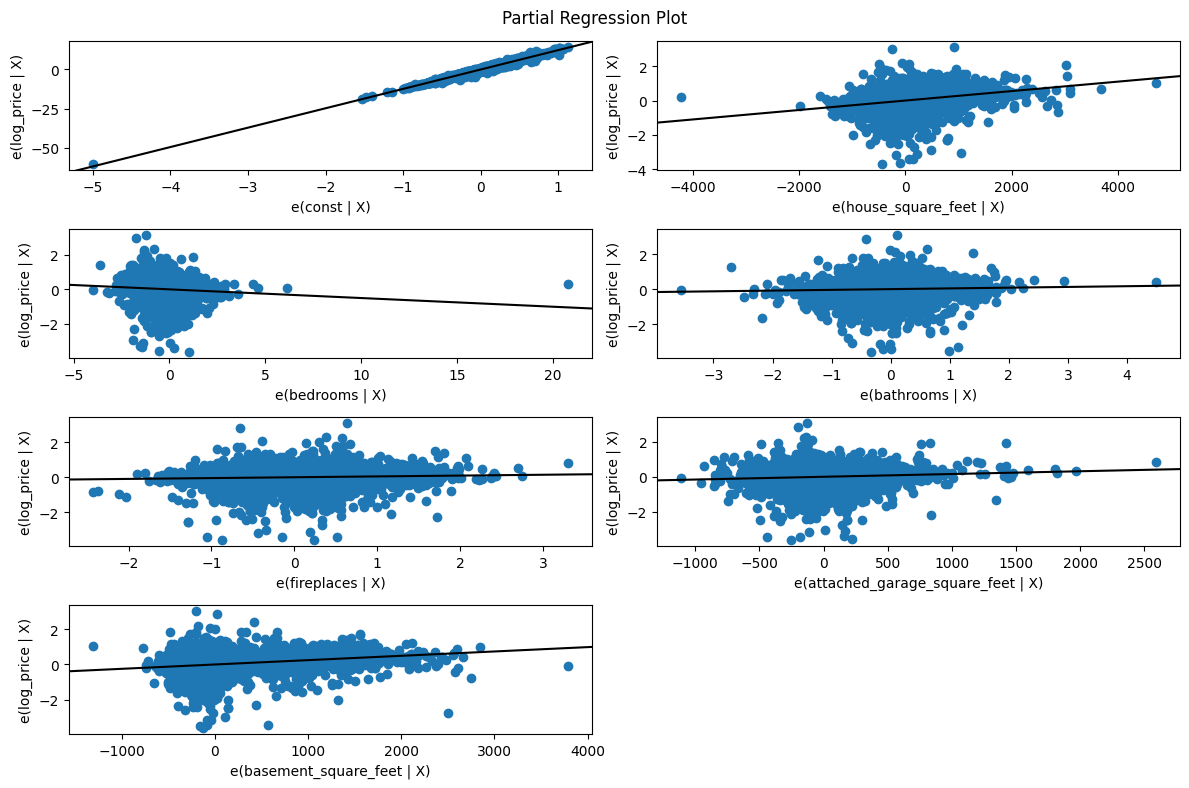

In [6]:
# Q5 - partial correlation plots for numeric variables
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Define features (use the same ones from your chosen model)
features = [
    'house_square_feet',
    'bedrooms',
    'bathrooms',
    'fireplaces',
    'attached_garage_square_feet',
    'basement_square_feet'
]

X_sm = X_train[features]

# Add constant (intercept)
X_sm = sm.add_constant(X_sm)

# Fit model
model_sm = sm.OLS(y_train, X_sm).fit()
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(model_sm, fig=fig)
plt.tight_layout()
plt.show()

Overall, most predictors exhibit approximately linear relationships with the response, supporting the use of a linear model. However, there was slight nonlinearity in variables such as house square footage and basement square footage, where the relationship flattened at higher values, suggesting diminishing marginal effects. Additionally, several plots show increasing spread in residuals as predictor values increase. While the deviations are not severe, they suggest that transformations or nonlinear terms could further improve model fit.

In [9]:
# Q6 -
import numpy as np
from sklearn.linear_model import LinearRegression

# Make copies
X_train_c = X_train.copy()
X_test_c = X_test.copy()
# log transforms
X_train_c['log_sqft'] = np.log(X_train_c['house_square_feet'])
X_test_c['log_sqft'] = np.log(X_test_c['house_square_feet'])
X_train_c['sqft_squared'] = X_train_c['house_square_feet']**2
X_test_c['sqft_squared'] = X_test_c['house_square_feet']**2
X_train_c['log_basement'] = np.log1p(X_train_c['basement_square_feet'])
X_test_c['log_basement'] = np.log1p(X_test_c['basement_square_feet'])

# interactions
X_train_c['sqft_bath'] = X_train_c['house_square_feet'] * X_train_c['bathrooms']
X_test_c['sqft_bath'] = X_test_c['house_square_feet'] * X_test_c['bathrooms']
X_train_c['sqft_garage'] = X_train_c['house_square_feet'] * X_train_c['attached_garage_square_feet']
X_test_c['sqft_garage'] = X_test_c['house_square_feet'] * X_test_c['attached_garage_square_feet']

# fit
model_complex = LinearRegression()
model_complex.fit(X_train_c, y_train)

# Predictions
y_train_pred = model_complex.predict(X_train_c)
y_test_pred = model_complex.predict(X_test_c)

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train RMSE: 0.30764883015655176
Test RMSE: 0.33230325857847043
Train R2: 0.4693726531972183
Test R2: 0.42902817594582543


Logarithmic and quadratic transformations of square footage were included to capture diminishing returns, and interaction terms between house size and other features were added to reflect joint effects. The more complex model showed improved performance on the training data and modest improvement on the test data, indicating that the added features captured some nonlinear structure. However, the gains were limited, suggesting that the simpler linear specification already captured much of the variation in housing prices.

Q7: From question 4, the simple linear models did not perform the best, but there was slight improvement when the number of features were increased to a certain point. This most likely indicates that including more features improves model performance, but also introduces a risk of overfitting, shown by differences between training and test performance. From question 5, most predictors exhibited linear relationships, but the nonlinearity inherent to certain variables made it difficult to accurately show the underlying distribution via correlation. It also showed that as predictors increased, residuals did as well, representing the risk of overfitting. The more complex model in question 6 shows that these phenomena are consistent even with log transforms, which are usually used to make the data more linear and easier to model. This also showed that while there were slight gains with making the model more complex, they were pretty minimal which indicates the need for a different model approach, as opposed to simply making it more complicated with more predictors and features. This was a very good example of a nonlinear dataset that is difficult to predict with a simple linear model. It showed how with small numbers of variables/features, the model is underfit and does not reflect the distribution or perform well, and when it becomes too complex it overfits the data and does not perform well. This reflects the need for a model that balances the two, that fits the training data well (with the right amount of complexity) while still allowing for generalization to test data.